# TerraMind Inference and Visualization
Load trained model, make predictions on Sen1Floods11 samples, and visualize results with RGB composites and ground truth overlay.

## 1. Import Required Libraries

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from terratorch.tasks import SemanticSegmentationTask
from terratorch.datamodules.sen1floods11 import Sen1Floods11NonGeoDataModule
from terra_sat_drift.data_simulation.phisat2_constants import S2_BANDS_NAMES, S2_BANDS

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 2. Load Trained Model and Datamodule

In [24]:
# Paths
data_root = Path("/shared/home/elucas/datasets/sen1floods11_simulated/")
output_dir = Path("/shared/home/elucas/terra-sat-drift/outputs/terramind_sen1floods_simulated")
checkpoint_path = output_dir / "checkpoints_stage1" / "best-val_mIoU.ckpt"

# Load datamodule
print("Loading datamodule...")
datamodule = Sen1Floods11NonGeoDataModule(
    data_root=str(data_root),
    bands=S2_BANDS_NAMES,
    num_workers=4,
    batch_size=8,
    download=False,
    use_metadata=True,
    output_bands=[
        "BLUE",
        "GREEN",
        "RED",
        "NIR_NARROW",
        "SWIR_1",
        "SWIR_2",
    ],
    rgb_indices=[2, 1, 0]
)
datamodule.setup(stage="test")
test_loader = datamodule.test_dataloader()
print(f"Test dataloader created with {len(test_loader)} batches")

# Load trained model
print("\nLoading trained model...")
if checkpoint_path.exists():
    model = SemanticSegmentationTask.load_from_checkpoint(str(checkpoint_path))
    print(f"Model loaded from: {checkpoint_path}")
else:
    print(f"Warning: Checkpoint not found at {checkpoint_path}")
    print(f"Available checkpoints: {list(output_dir.glob('**/*.ckpt'))}")
    
model.to(device)
model.eval()

Loading datamodule...
Test dataloader created with 12 batches

Loading trained model...


Loading datamodule...
Test dataloader created with 12 batches

Loading trained model...


2026-05-05 12:22:24,602 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-small/resolve/main/TerraMind_v1_small.pt "HTTP/1.1 302 Found"


Loading datamodule...
Test dataloader created with 12 batches

Loading trained model...


2026-05-05 12:22:24,602 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-small/resolve/main/TerraMind_v1_small.pt "HTTP/1.1 302 Found"


Model loaded from: /shared/home/elucas/terra-sat-drift/outputs/terramind_sen1floods_simulated/checkpoints_stage1/best-val_mIoU.ckpt


SemanticSegmentationTask(
  (model): PixelWiseModel(
    (encoder): TerraMindViT(
      (encoder_embeddings): ModuleDict(
        (untok_sen2l1c@224): ImageEncoderEmbedding(
          (proj): Linear(in_features=1792, out_features=384, bias=False)
        )
      )
      (encoder): ModuleList(
        (0-11): 12 x Block(
          (norm1): LayerNorm()
          (attn): Attention(
            (qkv): Linear(in_features=384, out_features=1152, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=384, out_features=384, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (drop_path): Identity()
          (norm2): LayerNorm()
          (mlp): Mlp(
            (fc1): Linear(in_features=384, out_features=1536, bias=True)
            (act): GELU(approximate='none')
            (fc2): Linear(in_features=1536, out_features=384, bias=True)
            (drop): Dropout(p=0.0, inplace=False)
          )
        )
 

## 3. Prepare Sample Data and Create RGB Composites

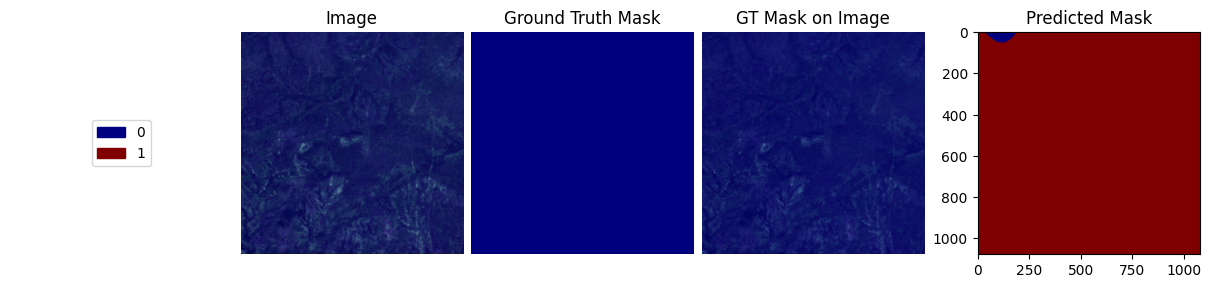

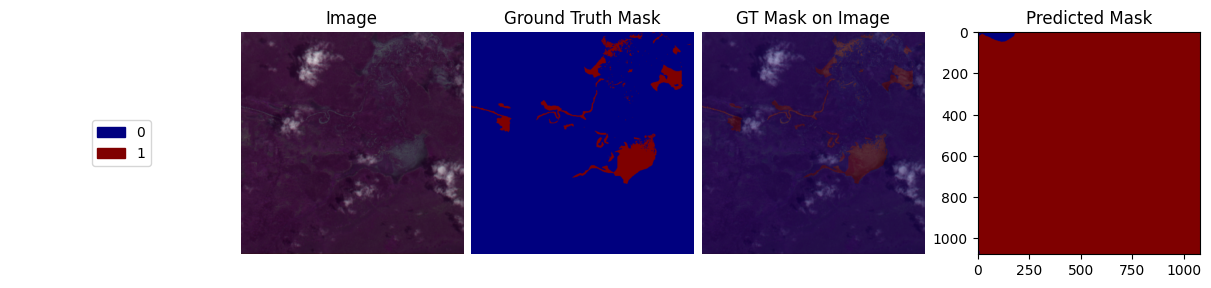

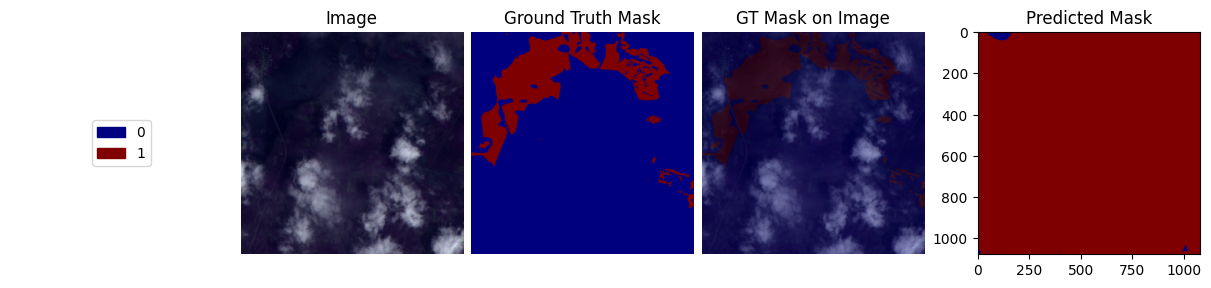

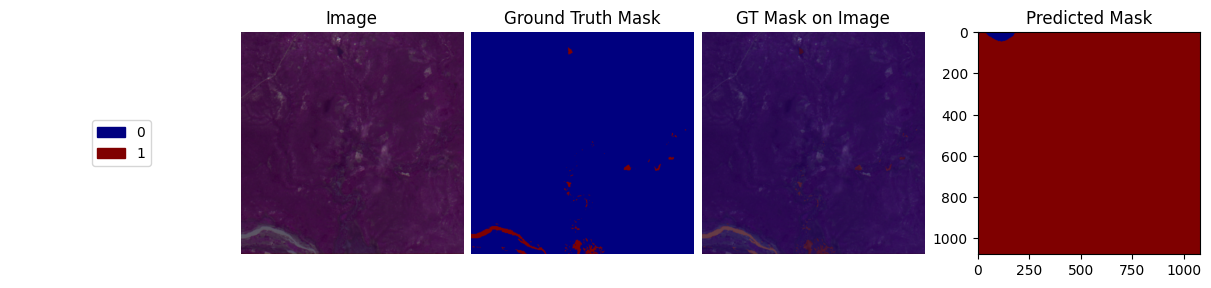

In [30]:
# Use the trained task for inference and visualization
model.eval()

# Get a batch from the test dataloader
datamodule.setup("test")
test_loader = datamodule.test_dataloader()
test_dataset = datamodule.test_dataset

with torch.no_grad():
    batch = next(iter(test_loader))
    images = batch["image"].to(model.device)
    masks = batch["mask"].cpu().numpy()

    outputs = model(images)
    preds = torch.argmax(outputs.output, dim=1).cpu().numpy()

# Visualize a few predictions
num_examples = min(6, len(preds))
for i in range(2, num_examples):
    sample = {
        "image": batch["image"][i].cpu(),
        "mask": batch["mask"][i].cpu(),
        "prediction": torch.from_numpy(preds[i])
    }
    test_dataset.plot(sample)

## 4. Generate Predictions

In [17]:
# Run inference
print("Running inference...")
with torch.no_grad():
    outputs = model(images)
    
# Convert logits to predictions
predictions = torch.argmax(outputs, dim=1).cpu().numpy()  # (B, H, W)
probabilities = torch.softmax(outputs, dim=1).cpu().numpy()  # (B, C, H, W)

# Get confidence scores (probability of predicted class)
confidence = probabilities[np.arange(batch_size), predictions]

print(f"Predictions shape: {predictions.shape}")
print(f"Prediction classes: {np.unique(predictions)}")
print(f"Confidence range: [{confidence.min():.3f}, {confidence.max():.3f}]")
print(f"GT classes: {np.unique(gt_masks)}")

Running inference...


TypeError: argmax(): argument 'input' (position 1) must be Tensor, not ModelOutput

## 5. Visualize Results with Ground Truth Overlay

In [ ]:
# Create custom colormaps for visualization
# 0 = no flood (blue), 1 = flood (red)
flood_colors = ['#0066ff', '#ff0000']  # Blue for no flood, Red for flood
flood_cmap = ListedColormap(flood_colors)

# Visualize first 4 samples
n_samples = min(4, batch_size)
fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4*n_samples))

if n_samples == 1:
    axes = axes.reshape(1, -1)

for idx in range(n_samples):
    # RGB composite
    ax = axes[idx, 0]
    ax.imshow(np.transpose(rgb_normalized[idx], (1, 2, 0)))
    ax.set_title(f"RGB Composite (Sample {idx})")
    ax.axis('off')
    
    # Prediction mask overlaid on RGB
    ax = axes[idx, 1]
    ax.imshow(np.transpose(rgb_normalized[idx], (1, 2, 0)))
    # Create semi-transparent mask overlay
    mask_overlay = np.zeros((h, w, 4))
    mask_overlay[predictions[idx] == 0] = [0, 0, 1, 0.3]  # Blue for no flood
    mask_overlay[predictions[idx] == 1] = [1, 0, 0, 0.4]  # Red for flood
    ax.imshow(mask_overlay)
    ax.set_title(f"Prediction Overlay")
    ax.axis('off')
    
    # Ground truth mask overlaid on RGB
    ax = axes[idx, 2]
    ax.imshow(np.transpose(rgb_normalized[idx], (1, 2, 0)))
    gt_overlay = np.zeros((h, w, 4))
    gt_overlay[gt_masks[idx] == 0] = [0, 0, 1, 0.3]  # Blue for no flood
    gt_overlay[gt_masks[idx] == 1] = [1, 0, 0, 0.4]  # Red for flood
    ax.imshow(gt_overlay)
    ax.set_title(f"Ground Truth Overlay")
    ax.axis('off')
    
    # Confidence map
    ax = axes[idx, 3]
    im = ax.imshow(confidence[idx], cmap='viridis', vmin=0, vmax=1)
    ax.set_title(f"Prediction Confidence")
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print(f"\n✓ Visualization complete!")
print(f"Samples shown: {n_samples}")
print(f"Classes: 0=No Flood (Blue), 1=Flood (Red)")

## (Optional) Statistics and Metrics

In [ ]:
# Calculate simple metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Flatten predictions and ground truth for comparison
pred_flat = predictions.flatten()
gt_flat = gt_masks.flatten()

accuracy = accuracy_score(gt_flat, pred_flat)
precision = precision_score(gt_flat, pred_flat, average='binary', zero_division=0)
recall = recall_score(gt_flat, pred_flat, average='binary', zero_division=0)
f1 = f1_score(gt_flat, pred_flat, average='binary', zero_division=0)

print("Metrics on Current Batch:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"\nPixel Distribution:")
print(f"  Predictions - No Flood: {(pred_flat == 0).sum()}, Flood: {(pred_flat == 1).sum()}")
print(f"  Ground Truth - No Flood: {(gt_flat == 0).sum()}, Flood: {(gt_flat == 1).sum()}")